Step 1. Open the dataset and examine the general information.

Paso 1. Abre el archivo de datos y estudia la información general:

In [ ]:
# cargar todas las librerias:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st
# Carga los archivo de datos:
df_games= pd.read_csv('/datasets/games.csv', sep= ',') 
display(df_games)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


Step 2. Prepare the data:

Paso 2. Prepara los datos: 

In [ ]:
# Reemplaza los nombres de las columnas (ponlos en minúsculas)
df_games.columns = df_games.columns.str.lower()
df_games

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16711,LMA Manager 2007,X360,2006.0,Sports,0.00,0.01,0.00,0.00,NaN,NaN,NaN
16712,Haitaka no Psychedelica,PSV,2016.0,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003.0,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [ ]:
# Convert the data into the appropriate data types.
#Convierte los datos en los tipos necesarios.
df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [ ]:
# The only column that needs to be converted is 'year_of_release', since years should be integers rather than floats.
# La única columna que cambia a tipo de dato es 'year_of release', debido a que las fechas no son float sino que son int.
df_games['year_of_release']= df_games['year_of_release'].astype('Int64')
df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: Int64(1), float64(5), object(5)
memory usage: 1.4+ MB


In [ ]:
# Number of missing values in the DataFrame:
#Número de datos ausentes para el DataFrame:
df_games.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64

**-** The values in the name column may be missing due to a data entry error.

**-** The values in the year_of_release column may be missing because the information was not available.

**-** The values in the critic_score, user_score, and rating columns may be missing because users did not complete the corresponding surveys.

**-** Los valores en la columna name pueden estar ausentes debido a un error.

**-** Los valores en la columna year_of_release pueden ser que no se tenía la información.

**-** Los valores en las columnas critic_score, user_score y rating puede que los usuarios no hayan respondido las encuestas de cada uno de ellos. 

In [ ]:

# Distribution of missing values:
# Distribución de valores ausentes:
print('distibucion de ausentes en year_of_release:')
print((df_games['year_of_release'].isna().sum()/len(df_games)).round(2)*100)

print('distibucion de ausentes en critic_score:')
print((df_games['critic_score'].isna().sum()/len(df_games)).round(2)*100)

print('distibucion de ausentes en user_score:')
print((df_games['user_score'].isna().sum()/len(df_games)).round(2)*100)

print('distibucion de ausentes en rating:')
print((df_games['rating'].isna().sum()/len(df_games)).round(2)*100)


distibucion de ausentes en year_of_release:
2.0
distibucion de ausentes en critic_score:
51.0
distibucion de ausentes en user_score:
40.0
distibucion de ausentes en rating:
40.0


In [ ]:
# The data in the following columns were inspected:
# Se inspeccionaron los datos de las siguientes columnas:
df_games['user_score'].unique()
df_games['rating'].unique()

array(['E', nan, 'M', 'T', 'E10+', 'K-A', 'AO', 'EC', 'RP'], dtype=object)

In [ ]:
# Once inspected, the missing values were filled using the following abbreviations:
# Una vez inspecionados llenamos los datos ausentes con las siguines abreviaciones:
#TBD: TIME TO BE DETERMINED 
#RP: RATING PENDING, 
# Se utilizan estas abreviaciones porque son parte de las especificaciones de la clasificación oficial de los juegos.
df_games.loc[df_games['user_score']== 'tbd', 'user_score']= np.nan
df_games['user_score']= df_games['user_score'].astype('float')
df_games['rating'] = df_games['rating'].fillna('RP')
df_games.isna().sum()

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating                0
dtype: int64

In [ ]:
# The total sales for each region are calculated and stored in a separate column.
# Se calculan las ventas totales para cada juego y coloca estos valores en una columna separada.
df_games['total_sales']= df_games['na_sales'] + df_games['eu_sales'] + df_games['jp_sales'] + df_games['other_sales']
df_games

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,NaN,NaN,RP,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,RP,31.38
...,...,...,...,...,...,...,...,...,...,...,...,...
16710,Samurai Warriors: Sanada Maru,PS3,2016,Action,0.00,0.00,0.01,0.00,NaN,NaN,RP,0.01
16711,LMA Manager 2007,X360,2006,Sports,0.00,0.01,0.00,0.00,NaN,NaN,RP,0.01
16712,Haitaka no Psychedelica,PSV,2016,Adventure,0.00,0.00,0.01,0.00,NaN,NaN,RP,0.01
16713,Spirits & Spells,GBA,2003,Platform,0.01,0.00,0.00,0.00,NaN,NaN,RP,0.01


Step 3. Analyze the data:

Paso 3. Analiza los datos:

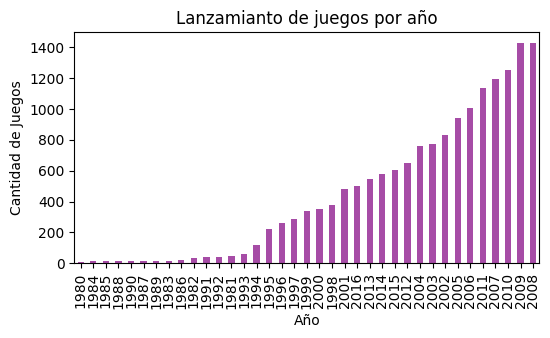

In [ ]:
# Games released in different years.
#Juegos que fueron lanzados en diferentes años.
games_relaese_per_year= df_games.groupby(['year_of_release'])['name'].count().sort_values()
#Se grafica para observar el la cantidad de juegos lanazados por año.
games_relaese_per_year.plot(kind= 'bar',
                            title='Lanzamianto de juegos por año',
                            xlabel= 'Año',
                            ylabel = 'Cantidad de Juegos',
                            color='Purple',
                            alpha=(0.7),
                            figsize=(6,3))
plt.show()

**-** The chart shows that the years with the highest number of games released were 2007 and 2008.

**-** Por medio de la gráfica se puede observar que los años con mayor cantidad de juegos lanzados fueron en el 2007 y el 2008.

In [ ]:
# Data distribution using a pivot table
# Distribución de los datos con pivot_table
df_games_pivot= df_games.pivot_table(index='year_of_release',
                                     columns='platform',
                                     values='total_sales',
                                     aggfunc='sum'
                                    ).fillna(0)
display(df_games_pivot)
display()
display(type(df_games_pivot))

platform,2600,3DO,3DS,DC,DS,GB,GBA,GC,GEN,GG,...,SAT,SCD,SNES,TG16,WS,Wii,WiiU,X360,XB,XOne
year_of_release,,,,,,,,,,,,,,,,,,,,,
1980,11.38,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1981,35.68,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1982,28.88,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1983,5.84,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1984,0.27,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1985,0.45,0.00,0.00,0.00,0.02,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1986,0.67,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1987,1.94,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1988,0.74,0.00,0.00,0.00,0.00,1.43,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


pandas.core.frame.DataFrame

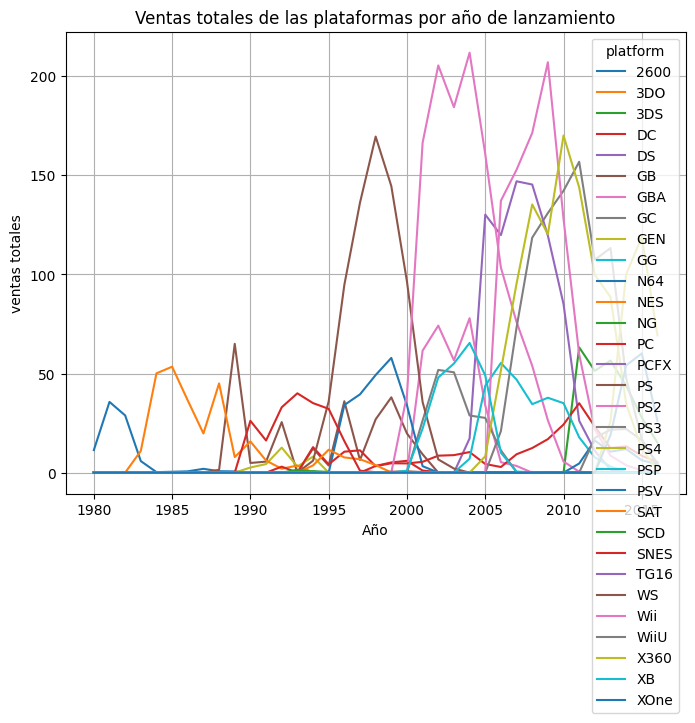

In [ ]:
# The distribution of the data is plotted:
# Se grafica la distribución de los datos:
df_games_pivot.plot(title='Ventas totales de las plataformas por año de lanzamiento',
                    xlabel= 'Año',
                    ylabel = 'ventas totales',
                    grid= True,
                    figsize=(8,6)
                   )  
plt.show()

**-** Based on the previous chart, it can be observed that new platforms generally have a lifecycle of approximately five years.

**_** Al observar la gráfica anterior, se puede observar que las nuevas plataformas generalemente tienen un ciclo de vida de 5 años.


In [ ]:
# Filter the data to obtain the new model using data from 2012 onward.
# Filtar los datos par aobtener el nuevo modelo con datos de el año 2012 en adelante:
new_model_games= df_games.query('year_of_release >= 2012')
new_model_games.head(3)


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
31,Call of Duty: Black Ops 3,PS4,2015,Shooter,6.03,5.86,0.36,2.38,NaN,NaN,RP,14.63


In [ ]:
# Data distribution using the new model with a pivot table.
# Distribución de datos con el nuevo modelo usando  pivot_table:
new_model_pivot= new_model_games.pivot_table(index='year_of_release',
                                     columns='platform',
                                     values='total_sales',
                                     aggfunc='sum'
                                    ).fillna(0)
new_model_pivot.head()

platform,3DS,DS,PC,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne
year_of_release,,,,,,,,,,,
2012,51.36,11.01,23.22,107.36,0.00,7.69,16.19,21.71,17.56,99.74,0.00
2013,56.57,1.54,12.38,113.25,25.99,3.14,10.59,8.59,21.65,88.58,18.96
2014,43.76,0.00,13.28,47.76,100.00,0.24,11.90,3.75,22.03,34.74,54.07
2015,27.78,0.00,8.52,16.82,118.90,0.12,6.25,1.14,16.35,11.96,60.14
2016,15.14,0.00,5.25,3.60,69.25,0.00,4.25,0.18,4.60,1.52,26.15


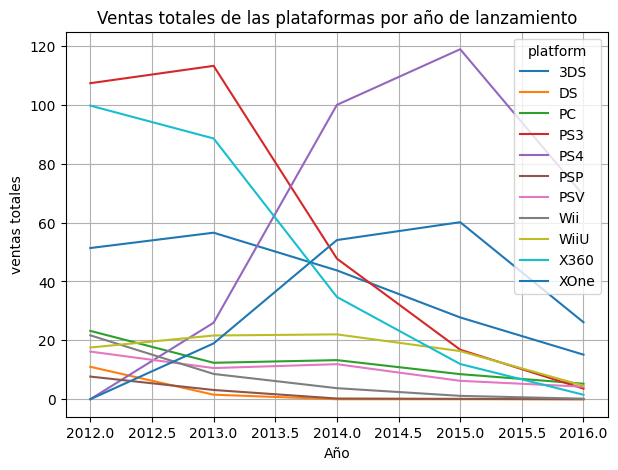

In [ ]:
# Distribution plot of the data using the new model:
# Grafico de la distibución de datos con el nuevo modelo:
new_model_pivot.plot(title='Ventas totales de las plataformas por año de lanzamiento',
                    xlabel= 'Año',
                    ylabel = 'ventas totales',
                    grid= True,
                    figsize=(7,5))
plt.show()


**-** Sales began to decline for PS4 in the first half of 2015.

**-** Las ventas empezaron a disminuir para PS4 en el primer semestre del año 2015.

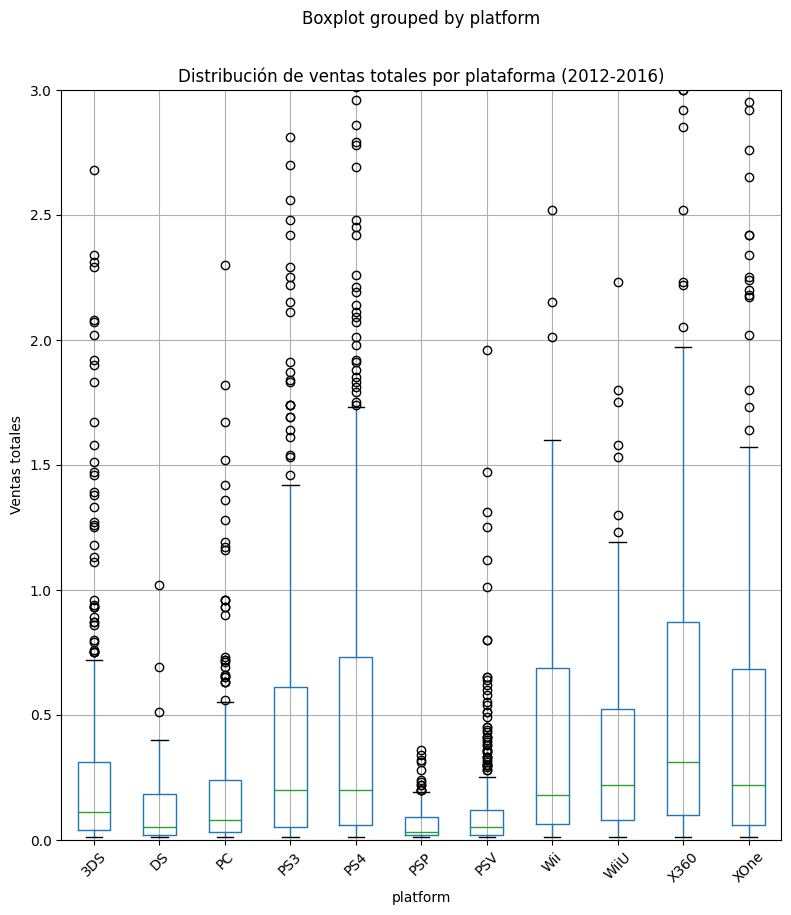

In [ ]:
# Create multiple box plots of total sales using the new dataset:
# Crear un boxplot total sales con new data set varios box plot:

new_model_games.boxplot(column='total_sales', by='platform', figsize=(9,10))
plt.title('Distribución de ventas totales por plataforma (2012-2016)')
plt.ylabel('Ventas totales')
plt.xticks(rotation=45)
plt.ylim(0,3)
plt.show()



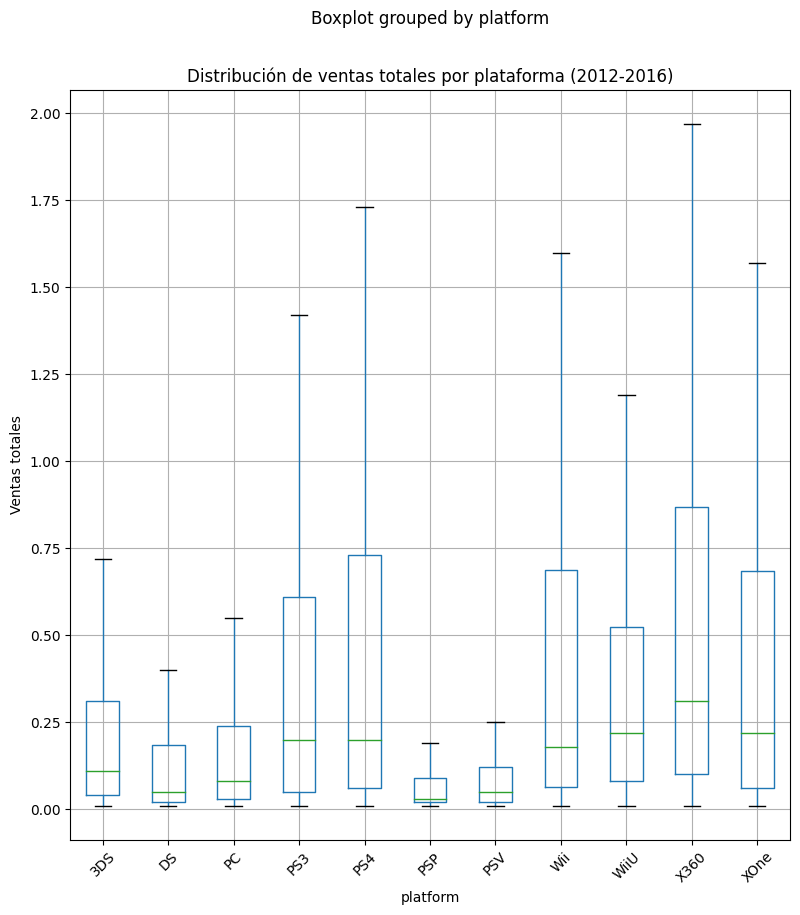

In [ ]:
new_model_games.boxplot(column='total_sales', by='platform', figsize=(9,10), showfliers = False) # nuevo parametro aquí
plt.title('Distribución de ventas totales por plataforma (2012-2016)')
plt.ylabel('Ventas totales')
plt.xticks(rotation=45)
#plt.ylim(0,3) ya no es necesario
plt.show()

**-** The platform with the highest number of sales is X360.

**-** La plataforma con el número mayor de ventas es X360.

In [ ]:
# Grouping construction:
# Construcción de agrupacion:
PS4= new_model_games.groupby(['platform','name'])[['total_sales','critic_score','user_score']].sum()
PS4= PS4.query('platform == "PS4" & critic_score >0 & user_score >0').reset_index()


In [ ]:
# Correlation calculation:
# Cálculo de correlación:
PS4['total_sales'].corr(PS4['critic_score'])*100

40.58948014583666

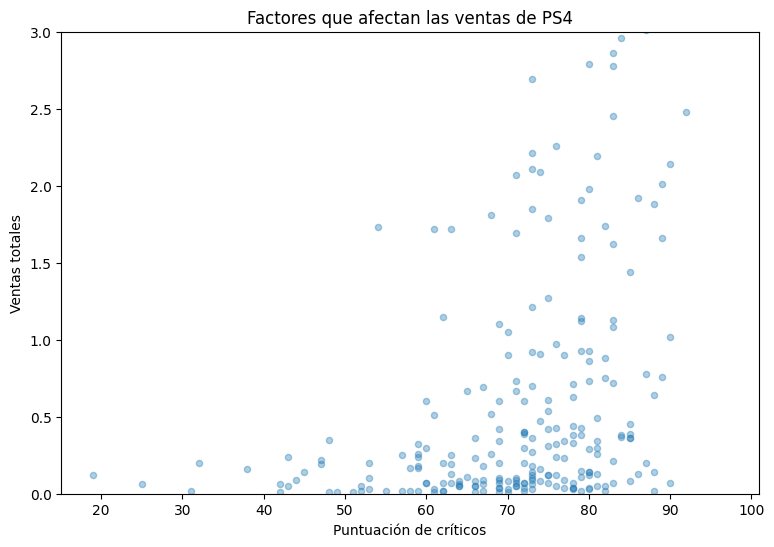

In [ ]:
# Create a scatter plot:
# Crear gráfico de dispersión:
PS4.plot(title='Factores que afectan las ventas de PS4',
         kind='scatter',
         x='critic_score',  
         y='total_sales',   
         alpha=0.36,
         figsize=[9,6],
         xlabel='Puntuación de críticos',
         ylabel='Ventas totales'
        )
plt.ylim(0,3)
plt.show()


**-** The correlation begins to increase within the 60 to 80 range.

**-** La correlación empieza a aumentar a partir de 60 a 80.


In [ ]:
# Comparison of total game sales across other platforms:
# Comparación de las ventas totales de los juegos en otras plataformas:
X360= new_model_games.groupby(['platform','name'])[['total_sales','critic_score','user_score']].sum()
X360= X360.query('platform == "X360" & critic_score >0 & user_score >0'). reset_index()

In [ ]:
X360['total_sales'].corr(X360['critic_score'])*100

36.057348885073395

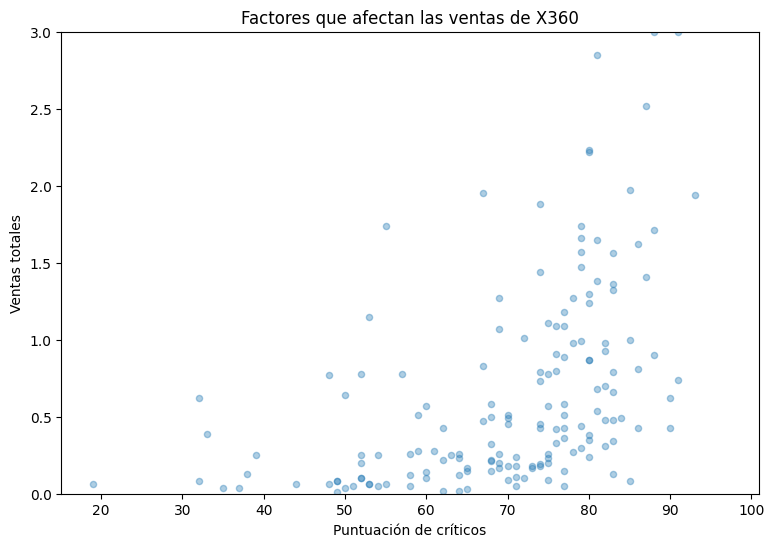

In [ ]:
# Create a scatter plot:
# Crear gráfico de dispersión:
X360.plot(title='Factores que afectan las ventas de X360',
           kind='scatter',
           x='critic_score',  
           y='total_sales',   
           alpha=0.36,
           figsize=[9,6],
           xlabel='Puntuación de críticos',
           ylabel='Ventas totales'
        )
plt.ylim(0,3)
plt.show()

**-** The correlation increases between 50 and 70, and then decreases from 80 onward.

**-** La correlación aumenta desde 50 a 70 y disminuye en 80 en adelante.

In [ ]:
# Function to calculate correlations:
# Funcón para calcular correlaciones:
def corr_function(plataformas):
    #filtar datos:
    data= new_model_games[new_model_games['platform']== plataformas]
    # calcular correlacion:
    corr= data[['critic_score','user_score','total_sales']].corr()['total_sales']
    #graficar:
    data.plot(title= plataformas,
              kind='scatter',
              x='critic_score',  
              y='total_sales',   
              alpha=0.36,
              figsize=[9,6],
              xlabel='Puntuación de críticos',
              ylabel='Ventas totales'

        ) 
    plt.show()
    print()
    
    data.plot(title= plataformas,
              kind='scatter',
              x='user_score',  
              y='total_sales',   
              alpha=0.36,
              figsize=[9,6],
              xlabel='Puntuación de ususarios',
              ylabel='Ventas totales'
        )
    plt.show()
    print(plataformas, corr)
    print('-'*50)
    
  
    

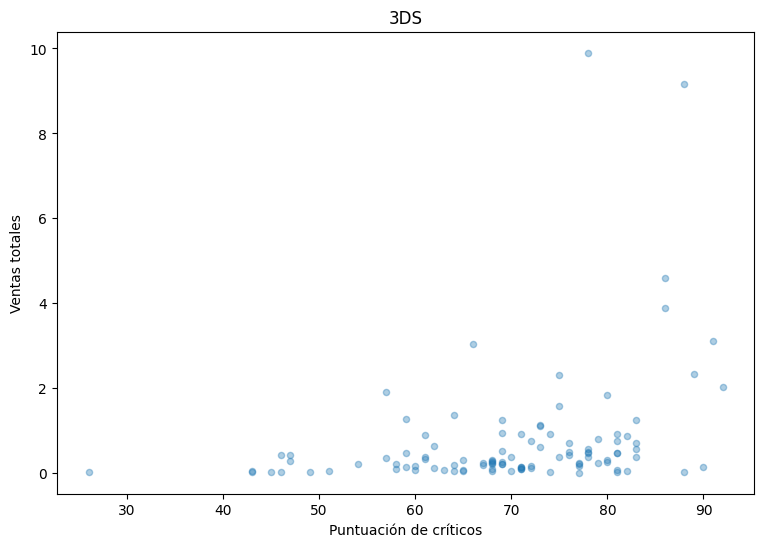

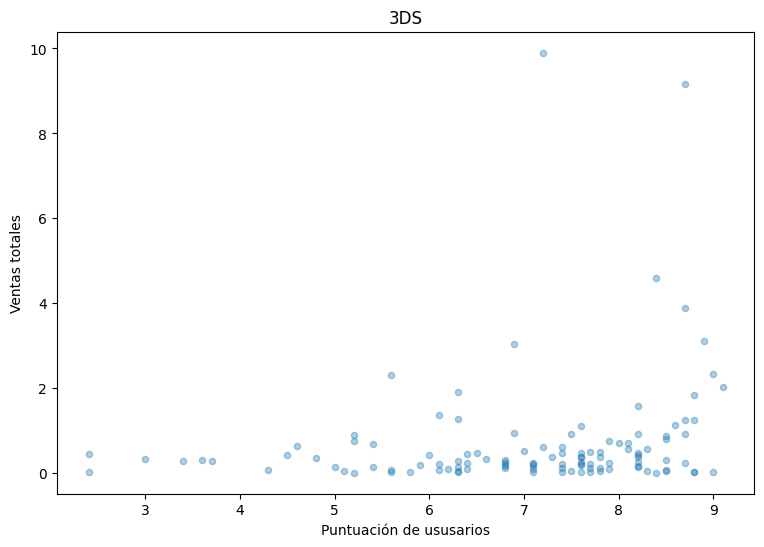

3DS critic_score    0.320803
user_score      0.197583
total_sales     1.000000
Name: total_sales, dtype: float64
--------------------------------------------------


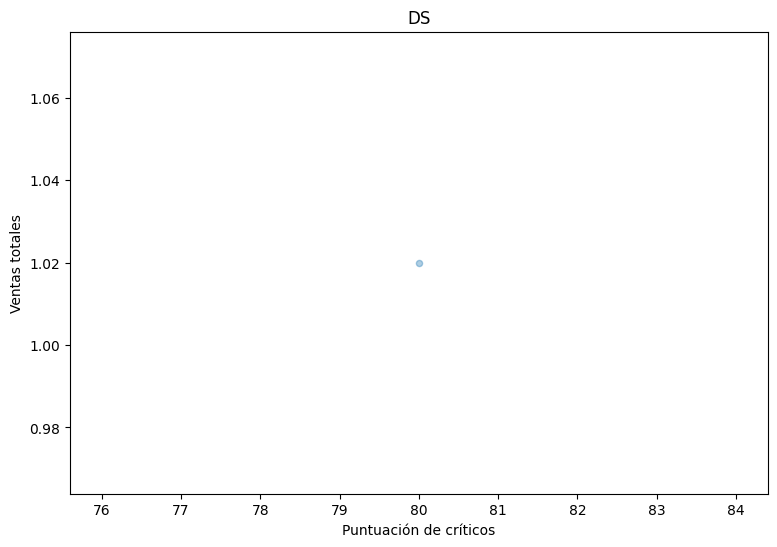

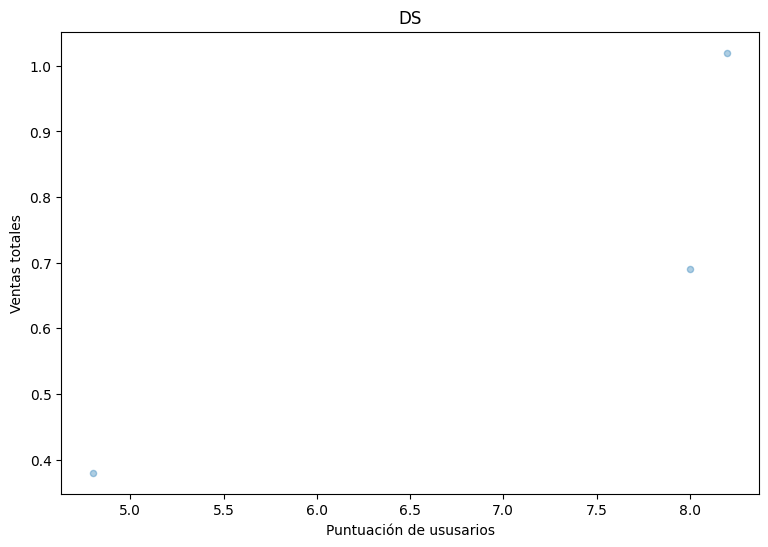

DS critic_score         NaN
user_score      0.882709
total_sales     1.000000
Name: total_sales, dtype: float64
--------------------------------------------------


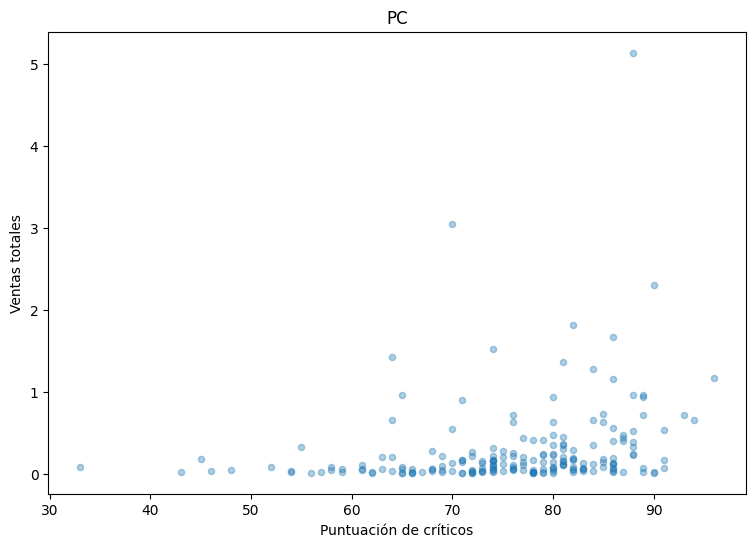

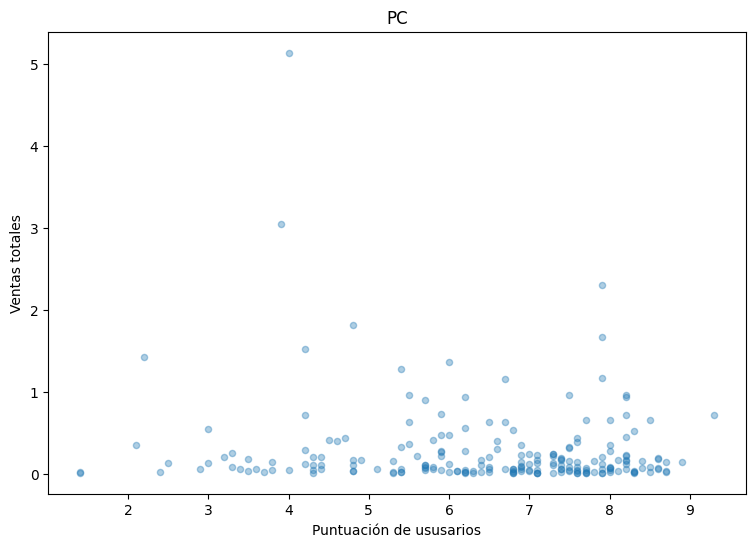

PC critic_score    0.237243
user_score     -0.121867
total_sales     1.000000
Name: total_sales, dtype: float64
--------------------------------------------------


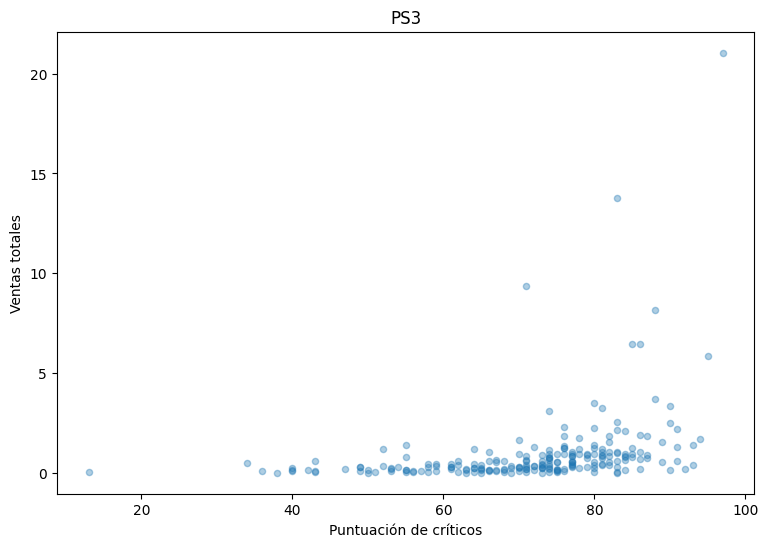

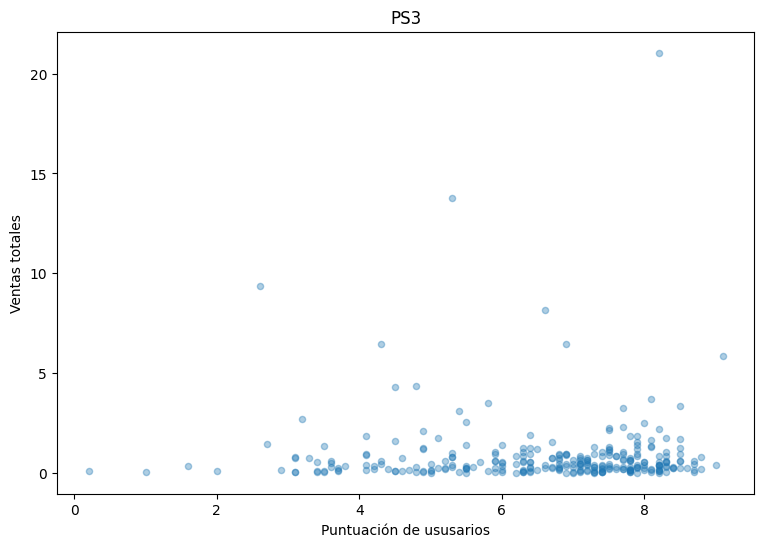

PS3 critic_score    0.331497
user_score     -0.005144
total_sales     1.000000
Name: total_sales, dtype: float64
--------------------------------------------------


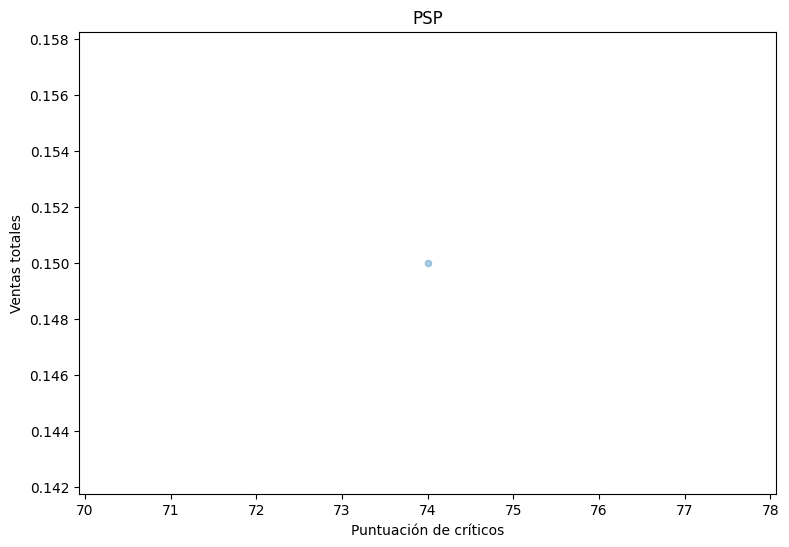

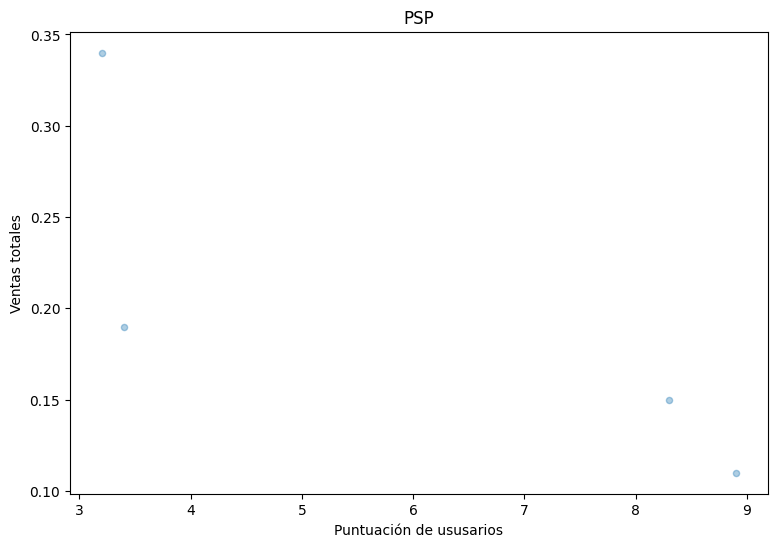

PSP critic_score         NaN
user_score     -0.802302
total_sales     1.000000
Name: total_sales, dtype: float64
--------------------------------------------------


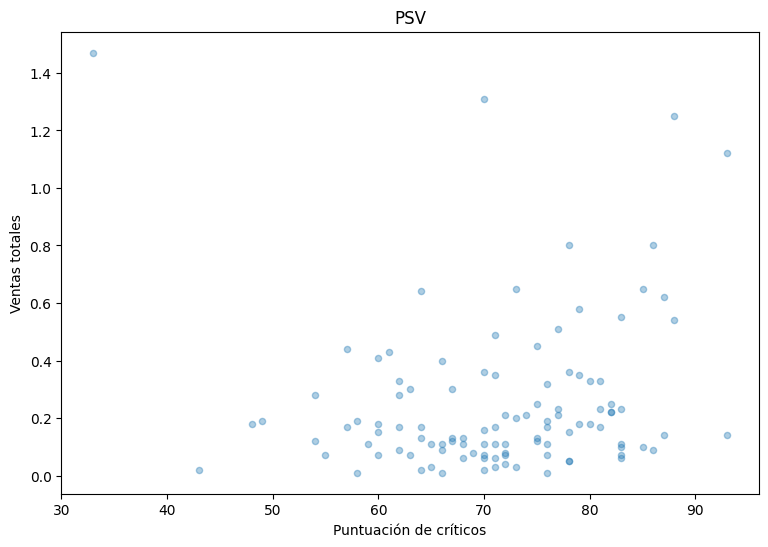

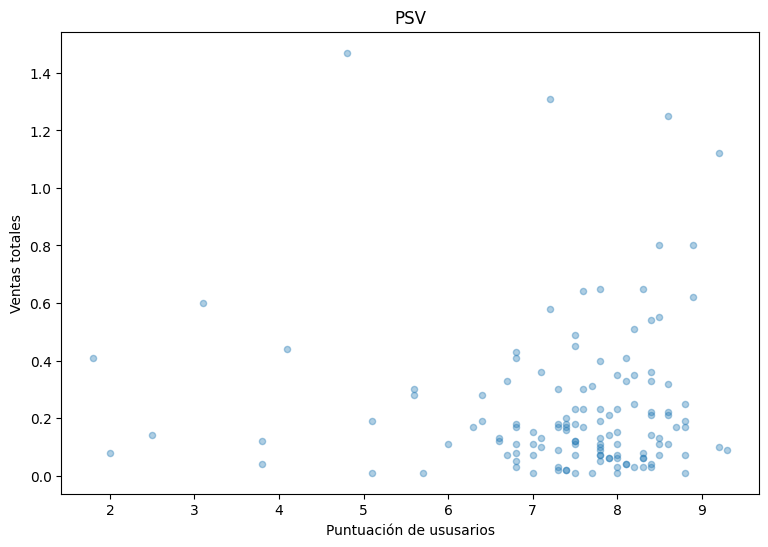

PSV critic_score    0.094488
user_score     -0.004339
total_sales     1.000000
Name: total_sales, dtype: float64
--------------------------------------------------


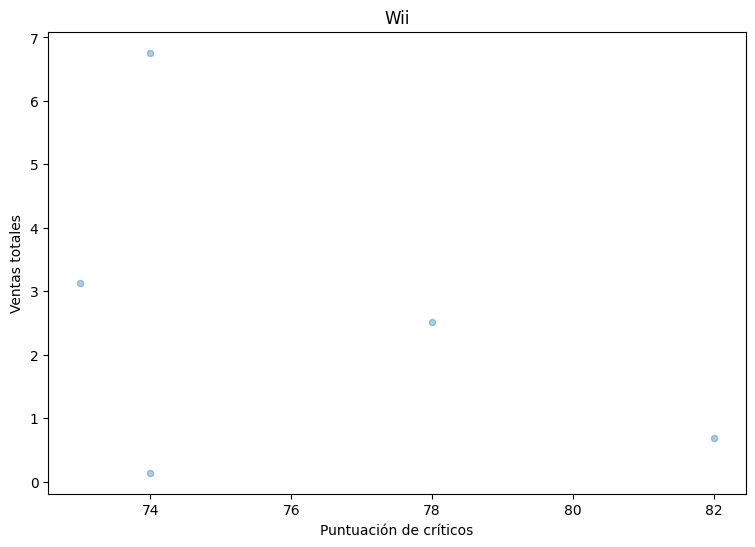

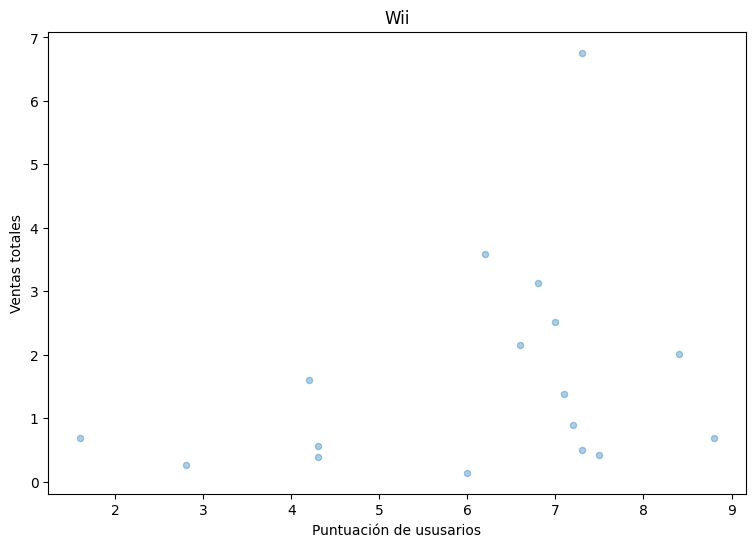

Wii critic_score   -0.424341
user_score      0.296197
total_sales     1.000000
Name: total_sales, dtype: float64
--------------------------------------------------


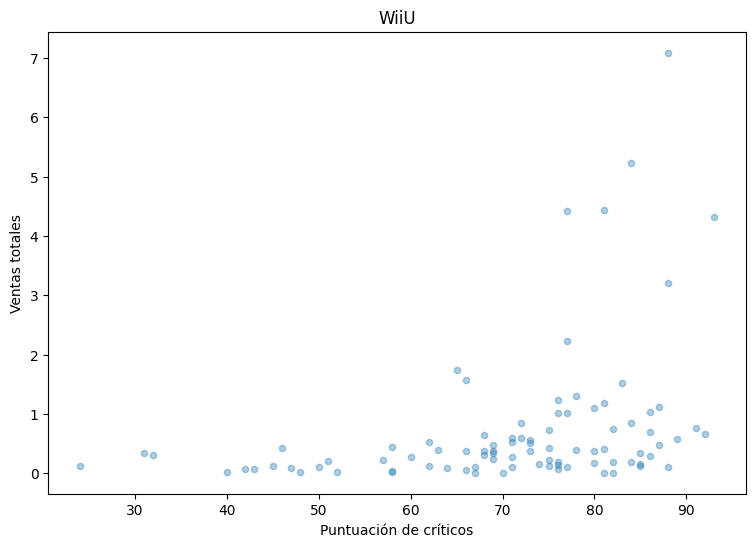

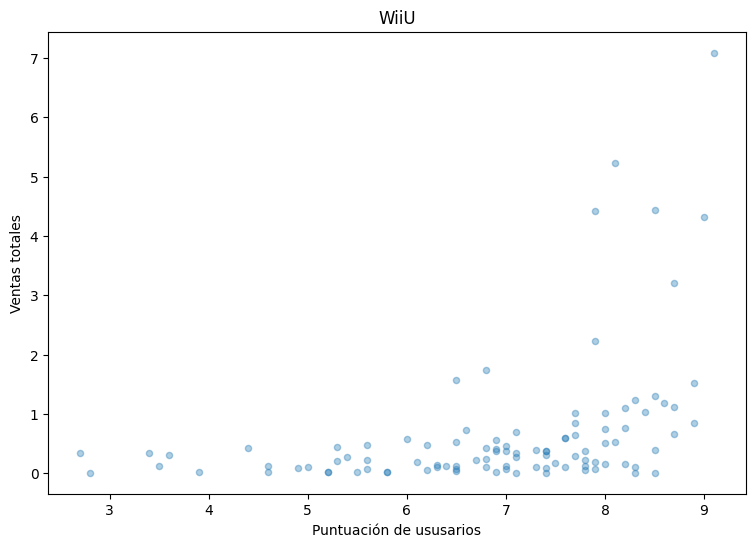

WiiU critic_score    0.348380
user_score      0.400219
total_sales     1.000000
Name: total_sales, dtype: float64
--------------------------------------------------


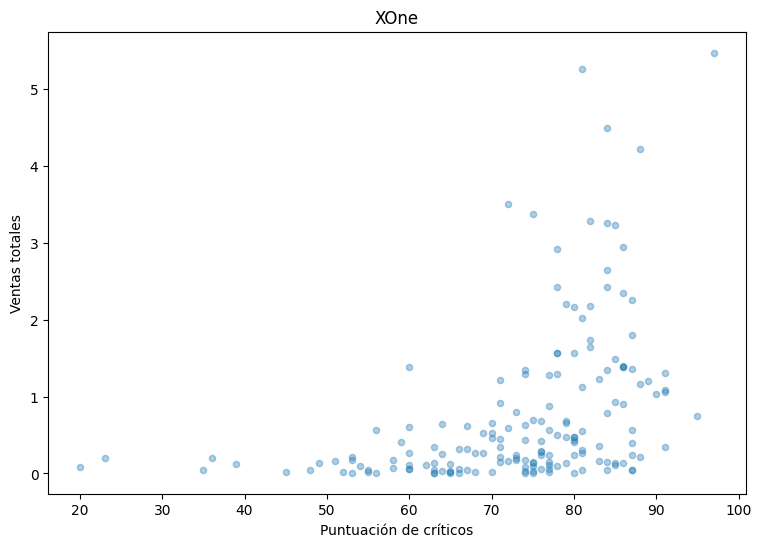

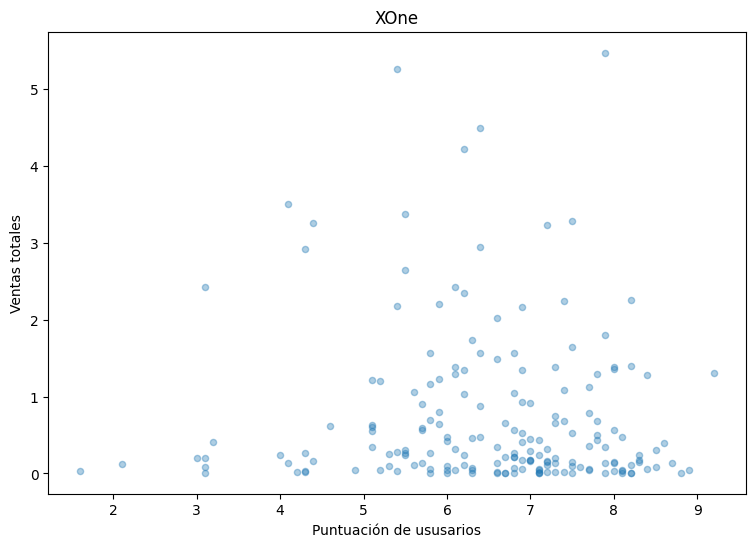

XOne critic_score    0.416998
user_score     -0.068925
total_sales     1.000000
Name: total_sales, dtype: float64
--------------------------------------------------


In [ ]:
# Iteration:
# Iteracion:
plataformas= ['3DS', 'DS', 'PC', 'PS3', 'PSP', 'PSV', 'Wii', 'WiiU', 'XOne']
for i in plataformas:
    corr_function(i)
 

**-** Through the function, the correlation for each platform can be observed.

**-** A través de la función se puede observar la correlación de cada plataforma.

In [ ]:
# Overall distribution of games by genre:
# Distribución general de los juegos por género:
sales_genre= new_model_games.groupby(['genre', 'name'])['total_sales'].sum().reset_index()
sales_genre= sales_genre.query('total_sales> 0')
sales_genre

,genre,name,total_sales
0,Action,.hack: Sekai no Mukou ni + Versus,0.03
1,Action,3rd Super Robot Wars Z: Tengoku-Hen,0.34
2,Action,7 Days to Die,0.19
3,Action,A Good Librarian Like a Good Shepherd: Library...,0.03
4,Action,AKB48+Me,0.11
...,...,...,...
1667,Strategy,Tropico 4: Modern Times,0.02
1668,Strategy,Ultraman Star Chronicles,0.02
1669,Strategy,War for the Overworld,0.01
1670,Strategy,XCOM 2,0.41


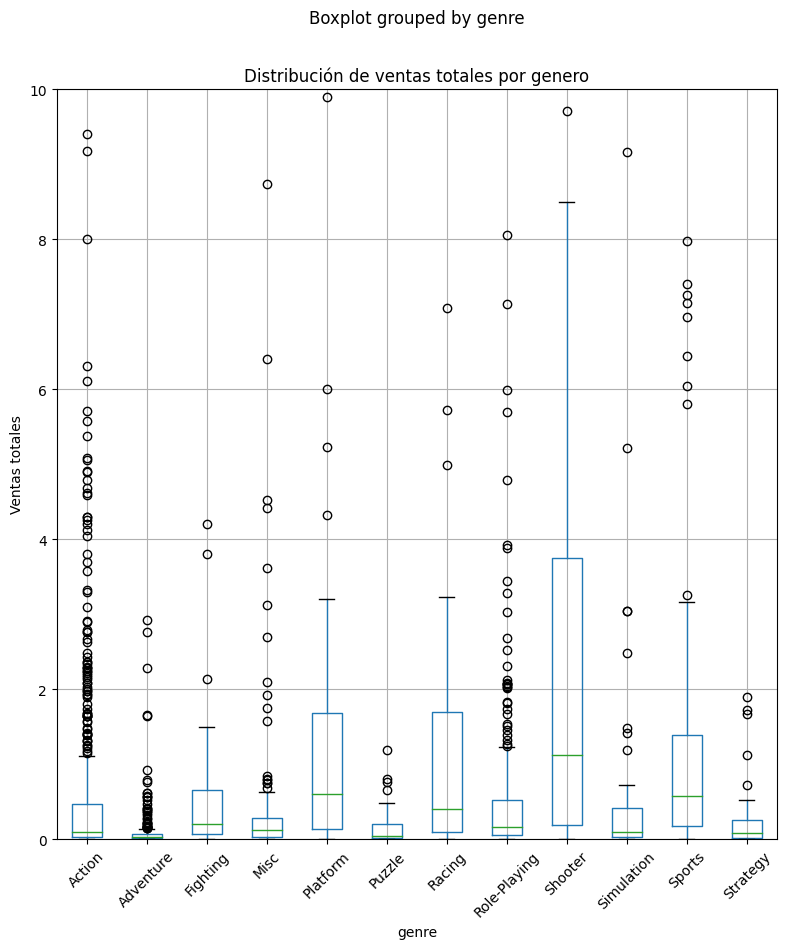

In [ ]:
sales_genre.boxplot(column='total_sales', by='genre', figsize=(9,10))
plt.title('Distribución de ventas totales por genero')
plt.ylabel('Ventas totales')
plt.xticks(rotation=45)
plt.ylim(0,10)
plt.show()
plt.show()

**-** The genre with the highest sales is Shooter, while Adventure has the lowest sales.

**-** El género que más ventas es shooter y con las ventas más bajas es adventure.

Step 4. Create a user profile for each region.

Paso 4. Crea un perfil de usuario para cada región


In [ ]:
# User profile for NA:
# Perfil de usuario para NA:
total_sales_na= new_model_games.groupby(['platform'])['na_sales'].sum().sort_values(ascending= False).reset_index()
print(total_sales_na)
print(total_sales_na.sum())

   platform  na_sales
0      X360    140.05
1       PS4    108.74
2       PS3    103.38
3      XOne     93.12
4       3DS     55.31
5      WiiU     38.10
6        PC     19.12
7       Wii     17.45
8       PSV     10.98
9        DS      4.59
10      PSP      0.13
platform    X360PS4PS3XOne3DSWiiUPCWiiPSVDSPSP
na_sales                                590.97
dtype: object


In [ ]:
# User profile for UE
# Perfil de usuario para UE:
total_sales_eu= new_model_games.groupby(['platform'])['eu_sales'].sum().sort_values(ascending= False).reset_index()
print(total_sales_eu)
print(total_sales_eu.sum())

   platform  eu_sales
0       PS4    141.09
1       PS3    106.86
2      X360     74.52
3      XOne     51.59
4       3DS     42.64
5        PC     37.76
6      WiiU     25.13
7       Wii     11.92
8       PSV     11.36
9        DS      3.53
10      PSP      0.42
platform    PS4PS3X360XOne3DSPCWiiUWiiPSVDSPSP
eu_sales                                506.82
dtype: object


In [ ]:
# User profile for JP:
# Perfil de usuario para JP:
total_sales_jp= new_model_games.groupby(['platform'])['jp_sales'].sum().sort_values(ascending= False).reset_index()
print(total_sales_jp)
print(total_sales_jp.sum())

   platform  jp_sales
0       3DS     87.79
1       PS3     35.29
2       PSV     21.04
3       PS4     15.96
4      WiiU     13.01
5       PSP     10.47
6        DS      3.72
7       Wii      3.39
8      X360      1.57
9      XOne      0.34
10       PC      0.00
platform    3DSPS3PSVPS4WiiUPSPDSWiiX360XOnePC
jp_sales                                192.58
dtype: object


In [ ]:
# The top five genres:
# Los cinco géneros principales: 
new_model_games.groupby(['genre'])['na_sales', 'eu_sales', 'jp_sales'].sum().sort_values(ascending= False, by= 'na_sales').reset_index()

,genre,na_sales,eu_sales,jp_sales
0,Action,177.84,159.34,52.80
1,Shooter,144.77,113.47,9.23
2,Sports,81.53,69.09,8.01
3,Role-Playing,64.00,48.53,65.44
4,Misc,38.19,26.32,12.86
5,Platform,25.38,21.41,8.63
6,Fighting,19.79,10.79,9.44
7,Racing,17.22,27.29,2.50
8,Adventure,8.92,9.46,8.24
9,Simulation,7.97,14.55,10.41


**-** In the Action, Shooter, Sports, and Misc genres, JP sales are influenced by NA and EU sales, whereas in the Role-Playing genre, sales remain stable across all three regions.

**-** En Action, Shooter, Sports y Misc JP_sales se ven afectadas por Na_sales y EU_sales, mientras que en el género Role-Playing las ventas de las tres regiones son estables. 

In [ ]:
# Entertainment Software Rating Board (Junta de Calificación de Software de Entretenimiento):
new_model_games.groupby(['rating'])['na_sales', 'eu_sales', 'jp_sales'].sum().sort_values(ascending= False, by= 'na_sales').reset_index()

,rating,na_sales,eu_sales,jp_sales
0,M,231.57,193.96,21.20
1,E,114.37,113.03,28.33
2,RP,103.31,91.50,108.84
3,E10+,75.70,55.37,8.19
4,T,66.02,52.96,26.02


**-** For the M, E, E10+, and T ratings, JP sales are influenced by NA and EU sales, whereas for the RP rating, sales remain stable across all three regions.

**-** Para el rating M, E, E10+ y T la región de JP_sales se ve afectada por las regiones de NA_sales y EU_sales, mientras que el rating RP sus ventas son estables para las 3 regiones.

Step 5. Test the following hypotheses:

Paso 5. Prueba las siguientes hipótesis:

In [ ]:
XOne_users= new_model_games[new_model_games['platform']== 'XOne']['user_score']
PC_users= new_model_games[new_model_games['platform']== 'PC']['user_score']
print(XOne_users.var())
print(PC_users.var())

1.9069968429360695
2.770443997158418


In [ ]:
# Null Hypothesis:
# Hipotesis nula:
alpha= 0.05

result= st.ttest_ind(XOne_users, PC_users, equal_var=False, nan_policy='omit')
print('p-valor:', result.pvalue)

if result.pvalue<alpha:
    print('Rechazamos la hipotesis nula')
else:
    print('No rechazamos la hipotesis nula')


p-valor: 0.5489537965134987
No rechazamos la hipotesis nula


**-** We do not reject the hypothesis that the average user ratings for the Xbox One and PC platforms are the same.

**-** No rechazamos la hipótesis de que las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.

In [ ]:
Action_users= new_model_games[new_model_games['genre']== 'Action']['user_score']
Sport_users= new_model_games[new_model_games['genre']== 'Sports']['user_score']
print(Action_users.var())
print(Sport_users.var())

1.8890840494348111
3.022890298704732


In [ ]:
# Alternative Hypothesis:
# Hipotesis alternativa:
alpha= 0.05

result= st.ttest_ind(Action_users, Sport_users, equal_var=False, nan_policy='omit')
print('p-valor:', result.pvalue)

if result.pvalue<alpha:
    print('Rechazamos la hipotesis nula')
else:
    print('No rechazamos la hipotesis nula')

p-valor: 4.24307776572644e-20
Rechazamos la hipotesis nula


**-** We reject the hypothesis that the average user ratings for the Action and Sports genres are different.

**-** Rechazamos la hipótesis de que las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

Bibliography

Bibliografia:

https://www.esrb.org/ratings-guide/es/
